In [51]:
#QUE 1

class ArrayStack:
    def __init__(self):
        self._data = []      # underlying array
        self._size = 0       # explicit size counter

    def __len__(self):
        return self._size

    def is_empty(self):
        return self._size == 0

    def push(self, item):
        if self._size == len(self._data):
            self._data.append(item)      # grow the array
        else:
            self._data[self._size] = item  # reuse the empty slot
        self._size += 1

    def top(self):
        if self.is_empty():
            raise IndexError("Stack is empty")
        return self._data[self._size - 1]

    def pop(self):
        if self.is_empty():
            raise IndexError("Stack is empty")

        value = self._data[self._size - 1]
        self._data[self._size - 1] = None
        self._size -= 1
        return value

In [10]:
s = ArrayStack()

s.push(10)
s.push(20)
s.push(30)

print(s.top())      # 30
print(s.pop())      # 30
print(s.top())      # 20
print(len(s))       # 2
print(s.is_empty()) # False

s.push(40)
print(s.top())      # 40

30
30
20
2
False
40


In [11]:
# QUE 2 

def is_balanced(expr):
    stack = ArrayStack()

    pairs = {
        ')': '(',
        ']': '[',
        '}': '{'
    }

    for ch in expr:
        if ch in "([{":
            stack.push(ch)

        elif ch in ")]}":
            if stack.is_empty():
                return False

            top = stack.pop()

            if top != pairs[ch]:
                return False

    return stack.is_empty()

In [12]:
print(is_balanced("()[]{}"))    # True
print(is_balanced("([{}])"))    # True
print(is_balanced("([)]"))      # False
print(is_balanced("((("))       # False
print(is_balanced("()))"))      # False

True
True
False
False
False


In [1]:
#QUE 3 

class ArrayQueue:
    def __init__(self, capacity=5):
        self.data = [None] * capacity
        self.front = 0
        self.size = 0

    def __len__(self):
        return self.size

    def is_empty(self):
        return self.size == 0

    def enqueue(self, item):
        if self.size == len(self.data):
            self.resize(2 * len(self.data))

        rear = (self.front + self.size) % len(self.data)
        self.data[rear] = item
        self.size += 1

    def dequeue(self):
        if self.is_empty():
            return "Queue is empty"

        item = self.data[self.front]
        self.data[self.front] = None
        self.front = (self.front + 1) % len(self.data)
        self.size -= 1
        return item

    def first(self):
        if self.is_empty():
            return "Queue is empty"
        return self.data[self.front]

    def resize(self, new_capacity):
        old = self.data
        self.data = [None] * new_capacity
        walk = self.front

        for i in range(self.size):
            self.data[i] = old[walk]
            walk = (walk + 1) % len(old)

        self.front = 0

    def show(self):
        print(self.data)



q = ArrayQueue(5)

q.enqueue(10)
q.enqueue(20)
q.enqueue(30)
q.show()

print("Dequeued:", q.dequeue())
q.show()

q.enqueue(40)
q.enqueue(50)
q.enqueue(60)   # wraps around
q.show()

print("Front element:", q.first())

[10, 20, 30, None, None]
Dequeued: 10
[None, 20, 30, None, None]
[60, 20, 30, 40, 50]
Front element: 20


In [5]:
#QUE 4
# ArrayStack (reuse from Q1)


# Queue using Two Stacks
class QueueUsingStacks:
    def __init__(self):
        self.in_stack = ArrayStack()
        self.out_stack = ArrayStack()

    def enqueue(self, item):
        self.in_stack.push(item)

    def dequeue(self):
        if self.out_stack.is_empty():
            while not self.in_stack.is_empty():
                self.out_stack.push(self.in_stack.pop())

        if self.out_stack.is_empty():
            return "Queue is empty"

        return self.out_stack.pop()

    def first(self):
        if self.out_stack.is_empty():
            while not self.in_stack.is_empty():
                self.out_stack.push(self.in_stack.pop())

        if self.out_stack.is_empty():
            return "Queue is empty"

        return self.out_stack.top()



q = QueueUsingStacks()

q.enqueue(10)
q.enqueue(20)
q.enqueue(30)

print(q.dequeue())   # 10
print(q.dequeue())   # 20

q.enqueue(40)

print(q.first())     # 30
print(q.dequeue())   # 30
print(q.dequeue())   # 40

10
20
30
30
40


In [6]:
#QUE 5

def reverse_queue(queue):
    stack = ArrayStack()

    while not queue.is_empty():
        stack.push(queue.dequeue())

    while not stack.is_empty():
        queue.enqueue(stack.pop())

In [7]:
q = ArrayQueue()
q.enqueue(1)
q.enqueue(2)
q.enqueue(3)
q.enqueue(4)

print("Original Queue:")
q.show()

reverse_queue(q)

print("Reversed Queue:")
q.show()

Original Queue:
[1, 2, 3, 4, None]
Reversed Queue:
[3, 2, 1, None, 4]


In [9]:
#QUE 6

class Deque:
    def __init__(self):
        self.data = []

    def add_first(self, item):
        self.data.insert(0, item)

    def add_last(self, item):
        self.data.append(item)

    def delete_first(self):
        if not self.data:
            return "Deque is empty"
        return self.data.pop(0)

    def delete_last(self):
        if not self.data:
            return "Deque is empty"
        return self.data.pop()

    def show(self):
        print(self.data)


d = Deque()

d.add_last(10)
d.add_last(20)
d.add_first(5)

d.show()                 # [5,10,20]

print(d.delete_first())  # 5
print(d.delete_last())   # 20

d.show()                 # [10]

[5, 10, 20]
5
20
[10]


In [10]:
import timeit
from collections import deque

# Python List
list_time = timeit.timeit(
    stmt="""
lst=[]
for i in range(100000):
    lst.insert(0,i)
for i in range(100000):
    lst.pop(0)
""",
    number=1
)

# collections.deque
deque_time = timeit.timeit(
    stmt="""
dq=deque()
for i in range(100000):
    dq.appendleft(i)
for i in range(100000):
    dq.popleft()
""",
    globals=globals(),
    number=1
)

print("List Time :", list_time)
print("Deque Time:", deque_time)

List Time : 2.857857040995441
Deque Time: 0.007432726997649297


In [11]:
#que 7
class ArrayStack:
    def __init__(self):
        self.data = []

    def push(self, x):
        self.data.append(x)

    def pop(self):
        return self.data.pop()

def evaluate_postfix(expression):
    stack = ArrayStack()

    for token in expression.split():
        if token.isdigit():
            stack.push(int(token))
        else:
            b = stack.pop()
            a = stack.pop()

            if token == '+':
                stack.push(a + b)
            elif token == '-':
                stack.push(a - b)
            elif token == '*':
                stack.push(a * b)
            elif token == '/':
                stack.push(a / b)

    return stack.pop()


expr = "3 4 + 2 *"
print("Answer:", evaluate_postfix(expr))

Answer: 14


In [12]:
# Q7 function

def evaluate_postfix(expression):
    stack = ArrayStack()

    for token in expression.split():
        if token.isdigit():
            stack.push(int(token))
        else:
            b = stack.pop()
            a = stack.pop()

            if token == '+':
                stack.push(a + b)
            elif token == '-':
                stack.push(a - b)
            elif token == '*':
                stack.push(a * b)
            elif token == '/':
                stack.push(a / b)

    return stack.pop()

In [13]:
# Infix → Postfix   #que 8 
def infix_to_postfix(expr):
    stack = ArrayStack()
    output = []
    priority = {'+':1, '-':1, '*':2, '/':2}

    for ch in expr:
        if ch.isdigit():
            output.append(ch)

        elif ch == '(':
            stack.push(ch)

        elif ch == ')':
            while stack.top() != '(':
                output.append(stack.pop())
            stack.pop()

        else:  # operator
            while (not stack.is_empty() and stack.top() != '('
                   and priority[stack.top()] >= priority[ch]):
                output.append(stack.pop())
            stack.push(ch)

    while not stack.is_empty():
        output.append(stack.pop())

    return " ".join(output)

In [16]:
expr = "(3+4)*2"

postfix = infix_to_postfix(expr)
answer = evaluate_postfix(postfix)

print("Infix   :", expr)
print("Postfix :", postfix)
print("Answer  :", answer)

Infix   : (3+4)*2
Postfix : 3 4 + 2 *
Answer  : 14


In [17]:
# QUE 9 
class TextEditor:
    def __init__(self):
        self.text = ""
        self.stack = []

    def type(self, txt):
        self.stack.append(self.text)   # Save previous state
        self.text += txt

    def undo(self):
        if self.stack:
            self.text = self.stack.pop()
        else:
            print("Nothing to undo")

    def show(self):
        print(self.text)

In [18]:
editor = TextEditor()

editor.type("Hello")
editor.show()

editor.type(" World")
editor.show()

editor.undo()
editor.show()

editor.undo()
editor.show()

Hello
Hello World
Hello



In [19]:
# QUE 10 

# Multiset ADT
# Operations:
# add(x)              -> insert an element
# remove(x)           -> remove one occurrence
# count(x)            -> return frequency of x
# distinct_elements() -> return all unique elements

class Multiset:
    def __init__(self):
        self.data = {}

    def add(self, item):
        self.data[item] = self.data.get(item, 0) + 1

    def remove(self, item):
        if item in self.data:
            self.data[item] -= 1
            if self.data[item] == 0:
                del self.data[item]

    def count(self, item):
        return self.data.get(item, 0)

    def distinct_elements(self):
        return list(self.data.keys())

In [20]:
bag = Multiset()

bag.add("apple")
bag.add("apple")
bag.add("banana")

print(bag.count("apple"))          # 2
print(bag.count("banana"))         # 1

bag.remove("apple")

print(bag.count("apple"))          # 1
print(bag.distinct_elements())     # ['apple', 'banana']

2
1
1
['apple', 'banana']


In [21]:
#QUE 11 

def multiset_intersection(list1, list2):
    counts = {}
    result = []

    # Count elements of first list
    for x in list1:
        counts[x] = counts.get(x, 0) + 1

    # Add common elements
    for x in list2:
        if counts.get(x, 0) > 0:
            result.append(x)
            counts[x] -= 1

    return result



a = [1, 2, 2, 3, 4]
b = [2, 2, 2, 4, 5]

print(multiset_intersection(a, b))

[2, 2, 4]


In [22]:
#QUE 12 
class MapADT:
    def __init__(self):
        self.data = []

    def __len__(self):
        return len(self.data)

    def getitem(self, key):
        for k, v in self.data:
            if k == key:
                return v
        return "Key not found"

    def setitem(self, key, value):
        for i, (k, v) in enumerate(self.data):
            if k == key:
                self.data[i] = (key, value)
                return
        self.data.append((key, value))

    def delitem(self, key):
        for i, (k, v) in enumerate(self.data):
            if k == key:
                del self.data[i]
                return
        return "Key not found"


In [23]:
m = MapADT()

m.setitem("name", "Prajakta")
m.setitem("age", 22)

print(m.getitem("name"))

m.delitem("age")

print(len(m))

Prajakta
1


In [24]:
#QUE 13 

def word_frequency(text):
    freq = {}

    words = text.lower().split()

    for word in words:
        word = word.strip(".,!?;:")
        freq[word] = freq.get(word, 0) + 1

    top5 = sorted(freq.items(), key=lambda x: x[1], reverse=True)[:5]

    print("Top 5 words:")
    for word, count in top5:
        print(word, ":", count)


In [25]:
paragraph = """
Python is easy. Python is powerful.
Python makes programming easy and fun.
"""

word_frequency(paragraph)

Top 5 words:
python : 3
is : 2
easy : 2
powerful : 1
makes : 1


In [26]:
#QUE 14 

class BiMap:
    def __init__(self):
        self.forward = {}
        self.backward = {}

    def insert(self, key, value):
        # Remove old mappings if they exist
        if key in self.forward:
            old_value = self.forward[key]
            del self.backward[old_value]

        if value in self.backward:
            old_key = self.backward[value]
            del self.forward[old_key]

        self.forward[key] = value
        self.backward[value] = key

    def delete_by_key(self, key):
        if key in self.forward:
            value = self.forward[key]
            del self.forward[key]
            del self.backward[value]

    def delete_by_value(self, value):
        if value in self.backward:
            key = self.backward[value]
            del self.backward[value]
            del self.forward[key]

    def get_value(self, key):
        return self.forward.get(key, "Not found")

    def get_key(self, value):
        return self.backward.get(value, "Not found")

In [27]:
b = BiMap()
b.insert("A", 1)
b.insert("B", 2)

print(b.get_value("A"))   # 1
print(b.get_key(2))       # B

b.delete_by_key("A")
print(b.get_value("A"))   # Not found

1
B
Not found


In [30]:
#QUE 15 

def union(a, b):
    result = []

    for x in a:
        if x not in result:
            result.append(x)

    for x in b:
        if x not in result:
            result.append(x)

    return result


def intersection(a, b):
    result = []

    for x in a:
        if x in b and x not in result:
            result.append(x)

    return result


def difference(a, b):
    result = []

    for x in a:
        if x not in b and x not in result:
            result.append(x)

    return result

In [31]:
A = [1,2,2,3]
B = [2,3,4]

print("Union:", union(A,B))
print("Intersection:", intersection(A,B))
print("Difference:", difference(A,B))

# Verification
print("Built-in Union:", list(set(A)|set(B)))
print("Built-in Intersection:", list(set(A)&set(B)))
print("Built-in Difference:", list(set(A)-set(B)))

Union: [1, 2, 3, 4]
Intersection: [2, 3]
Difference: [1]
Built-in Union: [1, 2, 3, 4]
Built-in Intersection: [2, 3]
Built-in Difference: [1]


In [32]:
#QUE 16 
class LRUCache:
    def __init__(self, capacity):
        self.capacity = capacity
        self.cache = {}     # key -> value
        self.order = []     # least recent at index 0

    def get(self, key):
        if key not in self.cache:
            return -1

        self.order.remove(key)
        self.order.append(key)
        return self.cache[key]

    def put(self, key, value):
        if key in self.cache:
            self.order.remove(key)

        elif len(self.cache) == self.capacity:
            old = self.order.pop(0)
            del self.cache[old]

        self.cache[key] = value
        self.order.append(key)

In [33]:
lru = LRUCache(3)

lru.put(1, "A")
lru.put(2, "B")
lru.put(3, "C")

print(lru.get(2))   # B

lru.put(4, "D")     # Removes key 1

print(lru.get(1))   # -1
print(lru.get(4))   # D

B
-1
D


[(1000, 4.6253204345703125e-05), (10000, 0.0004985332489013672), (100000, 0.018099546432495117), (1000000, 0.09584259986877441)]


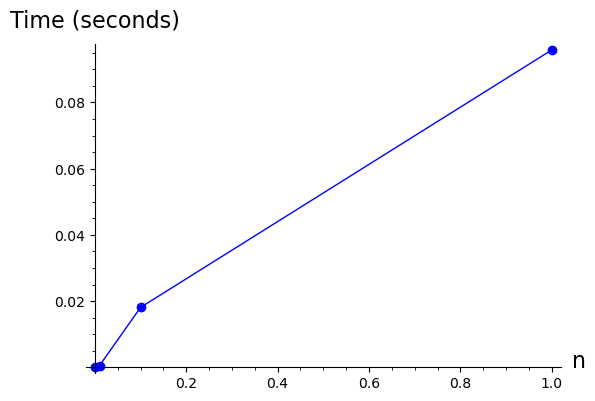

In [34]:
#QUE 17 

import time

points = []

sizes = [10**3, 10**4, 10**5, 10**6]

for n in sizes:
    lst = []
    start = time.time()

    for i in range(n):
        lst.append(i)

    end = time.time()
    points.append((n, end - start))

print(points)

# SageMath plot
list_plot(points, plotjoined=True, marker='o',
          axes_labels=['n', 'Time (seconds)'])

In [35]:
#QUE 18 

import random
import time

n = 100000

lst = list(range(n))
st = set(lst)

queries = [random.randint(0, n) for _ in range(1000)]

# List timing
start = time.time()
for x in queries:
    x in lst
list_time = time.time() - start

# Set timing
start = time.time()
for x in queries:
    x in st
set_time = time.time() - start

print("List:", list_time)
print("Set :", set_time)

List: 0.15406179428100586
Set : 0.0003075599670410156


In [36]:
# QUE 19 

import ctypes

class DynamicArray:
    def __init__(self):
        self.n = 0
        self.capacity = 1
        self.A = self.make_array(self.capacity)

    def __len__(self):
        return self.n

    def append(self, obj):
        if self.n == self.capacity:
            self.resize(2 * self.capacity)

        self.A[self.n] = obj
        self.n += 1

    def resize(self, new_capacity):
        print(f"Resizing {self.capacity} -> {new_capacity}")

        B = self.make_array(new_capacity)

        for i in range(self.n):
            B[i] = self.A[i]

        self.A = B
        self.capacity = new_capacity

    def make_array(self, c):
        return (c * ctypes.py_object)()

    def show(self):
        for i in range(self.n):
            print(self.A[i], end=" ")
        print()


In [37]:
arr = DynamicArray()

for i in range(10):
    arr.append(i)

arr.show()

Resizing 1 -> 2
Resizing 2 -> 4
Resizing 4 -> 8
Resizing 8 -> 16
0 1 2 3 4 5 6 7 8 9 


In [38]:
#QUE 20 

import ctypes

class DynamicArray:
    def __init__(self):
        self.n = 0
        self.capacity = 1
        self.copies = 0
        self.A = self.make_array(self.capacity)

    def append(self, obj):
        if self.n == self.capacity:
            self.resize(2 * self.capacity)

        self.A[self.n] = obj
        self.n += 1

    def resize(self, new_capacity):
        B = self.make_array(new_capacity)

        for i in range(self.n):
            B[i] = self.A[i]
            self.copies += 1

        self.A = B
        self.capacity = new_capacity

    def make_array(self, c):
        return (c * ctypes.py_object)()


arr = DynamicArray()

for i in range(1000):
    arr.append(i)

print("Total Copies:", arr.copies)

Total Copies: 1023


In [39]:
#QUE 21

def remove_duplicates(lst):
    seen = set()
    result = []

    for x in lst:
        if x not in seen:
            seen.add(x)
            result.append(x)

    return result


print(remove_duplicates([1,2,2,3,1,4,3]))

[1, 2, 3, 4]


In [40]:
#QUE 22

def reflect(point):
    x, y = point
    return (y, x)

print(reflect((3,7)))

(7, 3)


In [41]:
# QUE 23

class Matrix:
    def __init__(self, data):
        self.data = data

    def add(self, other):
        rows = len(self.data)
        cols = len(self.data[0])

        result = [[0]*cols for _ in range(rows)]

        for i in range(rows):
            for j in range(cols):
                result[i][j] = self.data[i][j] + other.data[i][j]

        return Matrix(result)

    def multiply(self, other):
        rows = len(self.data)
        cols = len(other.data[0])
        common = len(other.data)

        result = [[0]*cols for _ in range(rows)]

        for i in range(rows):
            for j in range(cols):
                for k in range(common):
                    result[i][j] += self.data[i][k]*other.data[k][j]

        return Matrix(result)

    def show(self):
        for row in self.data:
            print(row)

In [42]:
A = Matrix([[1,2],[3,4]])
B = Matrix([[5,6],[7,8]])

A.add(B).show()
print()
A.multiply(B).show()

[6, 8]
[10, 12]

[19, 22]
[43, 50]


In [44]:
#QUE 24 

class PriorityBag:
    def __init__(self):
        self.data = []

    def insert(self, item, priority):
        self.data.append((item, priority))

    def remove_highest_priority(self):
        if not self.data:
            return "Empty"

        max_index = 0

        for i in range(1, len(self.data)):
            if self.data[i][1] > self.data[max_index][1]:
                max_index = i

        return self.data.pop(max_index)



In [45]:
p = PriorityBag()

p.insert("A",2)
p.insert("B",5)
p.insert("C",3)

print(p.remove_highest_priority())

('B', 5)


In [46]:
#QUE 25 

from collections import deque

def hot_potato(n, k):
    q = deque(range(1, n+1))
    order = []

    while len(q) > 1:
        for _ in range(k-1):
            q.append(q.popleft())
        order.append(q.popleft())

    print("Elimination:", order)
    print("Winner:", q[0])

# Demo
hot_potato(5,3)

Elimination: [3, 1, 5, 2]
Winner: 4


In [47]:
#QUE 26

import random
import time

words = ["python","data","stack","queue","tree","graph"]
text = [random.choice(words) for _ in range(10000)]

# Dictionary
start = time.time()
d = {}
for w in text:
    d[w] = d.get(w,0)+1
dict_time = time.time()-start

# List
start = time.time()
pairs = []

for w in text:
    found = False

    for i,(word,count) in enumerate(pairs):
        if word == w:
            pairs[i] = (word,count+1)
            found = True
            break

    if not found:
        pairs.append((w,1))

list_time = time.time()-start

print("Dictionary:",dict_time)
print("List:",list_time)

Dictionary: 0.0013363361358642578
List: 0.004312992095947266


In [48]:
#QUE 27 

class SparseVector:
    def __init__(self):
        self.data = {}

    def set(self,index,value):
        if value != 0:
            self.data[index] = value

    def add(self,other):
        result = SparseVector()

        result.data = self.data.copy()

        for i,v in other.data.items():
            result.data[i] = result.data.get(i,0)+v

        return result

    def dot(self,other):
        total = 0

        for i,v in self.data.items():
            total += v*other.data.get(i,0)

        return total


In [49]:
v1 = SparseVector()
v1.set(1,5)
v1.set(100,3)

v2 = SparseVector()
v2.set(1,2)
v2.set(100,4)

print(v1.dot(v2))

22


In [53]:
# QUE 28 

class ArrayStack:
    def __init__(self):
        self.data=[]

    def push(self,x):
        self.data.append(x)

    def pop(self):
        if self.data:
            self.data.pop()

def simulate(operations):
    s = ArrayStack()

    for op in operations:
        parts = op.split()

        if parts[0] == "push":
            s.push(int(parts[1]))
        elif parts[0] == "pop":
            s.pop()

    return s.data

ops = ["push 3","push 5","pop","push 8"]
print(simulate(ops))

[3, 8]


In [58]:
# QUE 29 
import random

def dict_union(a, b):
    d = {}
    for x in a:
        d[x] = True
    for x in b:
        d[x] = True
    return list(d.keys())

def dict_intersection(a, b):
    d1 = {}
    result = {}

    for x in a:
        d1[x] = True

    for x in b:
        if x in d1:
            result[x] = True

    return list(result.keys())

def symmetric_difference(a, b):
    d1 = {}
    d2 = {}
    result = {}

    # Make unique dictionaries
    for x in a:
        d1[x] = True

    for x in b:
        d2[x] = True

    # Elements only in A
    for x in d1:
        if x not in d2:
            result[x] = True

    # Elements only in B
    for x in d2:
        if x not in d1:
            result[x] = True

    return sorted(result.keys())


# Verification
for _ in range(10):
    A = [random.randint(1,5) for _ in range(5)]
    B = [random.randint(1,5) for _ in range(5)]
    assert symmetric_difference(A,B) == symmetric_difference(B,A)

print("Verified on 10 random pairs")

Verified on 10 random pairs


In [60]:
# QUE 30 

from abc import ABC, abstractmethod

class Container(ABC):

    @abstractmethod
    def add(self,item): pass

    @abstractmethod
    def remove(self,item): pass

    @abstractmethod
    def contains(self,item): pass


class ListContainer(Container):
    def __init__(self):
        self.data=[]

    def add(self,item):
        self.data.append(item)

    def remove(self,item):
        if item in self.data:
            self.data.remove(item)

    def contains(self,item):
        return item in self.data


class SetContainer(Container):
    def __init__(self):
        self.data=set()

    def add(self,item):
        self.data.add(item)

    def remove(self,item):
        self.data.discard(item)

    def contains(self,item):
        return item in self.data




In [61]:
containers=[ListContainer(),SetContainer()]

for c in containers:
    c.add(10)
    c.add(20)
    c.remove(10)
    print(type(c).__name__, c.contains(20))

ListContainer True
SetContainer True
